# Consumer Complaint Classification

## 1. Import Libraries

In [50]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load Preprocessed Data

In [51]:
X_train = np.load("/kaggle/working/X_train.npy")
X_test = np.load("/kaggle/working/X_test.npy")

y_train = np.load("/kaggle/working/y_train.npy")
y_test = np.load("/kaggle/working/y_test.npy")

with open("/kaggle/working/label_encoder.pkl","rb") as f:
    label_encoder = pickle.load(f)

with open("/kaggle/working/tokenizer.pkl","rb") as f:
    tokenizer = pickle.load(f)

## 3. Build SimpleRNN Model

In [53]:
VOCAB_SIZE = 20000

MAX_LEN = 240

EMBEDDING_DIM = 128

RNN_UNITS = 128

DENSE_UNITS = 64

DROPOUT_RATE = 0.5

BATCH_SIZE = 128

EPOCHS = 20

NUM_CLASSES = len(label_encoder.classes_)

In [54]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    SpatialDropout1D(0.2),

    SimpleRNN(

        RNN_UNITS,

        dropout=0.2,

        recurrent_dropout=0.2

    ),

    Dense(

        DENSE_UNITS,

        activation="relu"

    ),

    Dropout(DROPOUT_RATE),

    Dense(

        NUM_CLASSES,

        activation="softmax"

    )

])

model.build(input_shape=(None, MAX_LEN))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 240, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 240, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,477 (9.92 MB)

 Trainable params: 2,601,477 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [56]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "/kaggle/working/best_simplernn.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

## 4. Train Model

In [57]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test, y_test),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/20
   3/1016 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.1719 - loss: 1.7886  

I0000 00:00:1784461949.835240     298 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5326 - loss: 1.2721
Epoch 1: val_accuracy improved from None to 0.59037, saving model to /kaggle/working/best_simplernn.keras

Epoch 1: finished saving model to /kaggle/working/best_simplernn.keras
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.5768 - loss: 1.1244 - val_accuracy: 0.5904 - val_loss: 1.0254 - learning_rate: 0.0010
Epoch 2/20
1015/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6179 - loss: 0.9707
Epoch 2: val_accuracy improved from 0.59037 to 0.63840, saving model to /kaggle/working/best_simplernn.keras

Epoch 2: finished saving model to /kaggle/working/best_simplernn.keras
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.6219 - loss: 0.9539 - val_accuracy: 0.6384 - val_loss: 0.8836 - learning_rate: 0.0010
Epoch 3/20
1014/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6345 - loss: 0.9119
Epoch 3: val_accuracy improved from 0.63840 to 0.64926, saving model to /kaggle/working/best_si

## 5. Evaluate Model

In [58]:
# Predictions
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step


In [59]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7611
Precision: 0.6027
Recall   : 0.6366
F1 Score : 0.5918


In [60]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                     precision    recall  f1-score   support

        credit_card       0.33      0.05      0.08      3113
   credit_reporting       0.89      0.90      0.89     18235
    debt_collection       0.66      0.69      0.68      4630
mortgages_and_loans       0.59      0.75      0.66      3798
     retail_banking       0.55      0.79      0.65      2707

           accuracy                           0.76     32483
          macro avg       0.60      0.64      0.59     32483
       weighted avg       0.74      0.76      0.74     32483



## 6. Visualize Results

<Figure size 800x800 with 0 Axes>

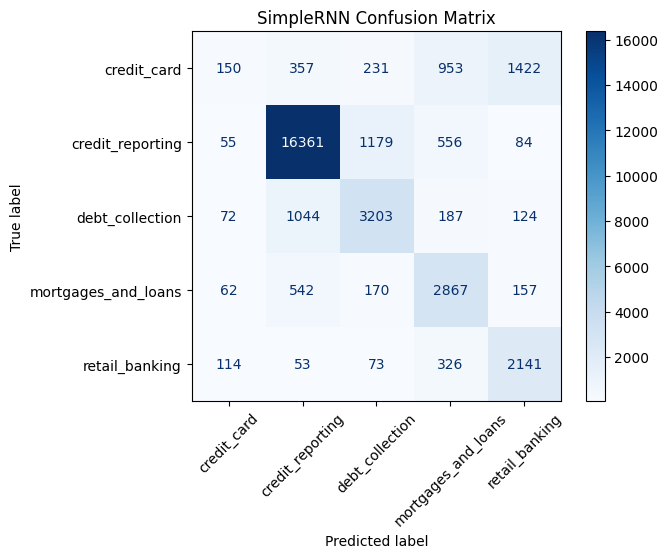

In [61]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("SimpleRNN Confusion Matrix")

plt.show()

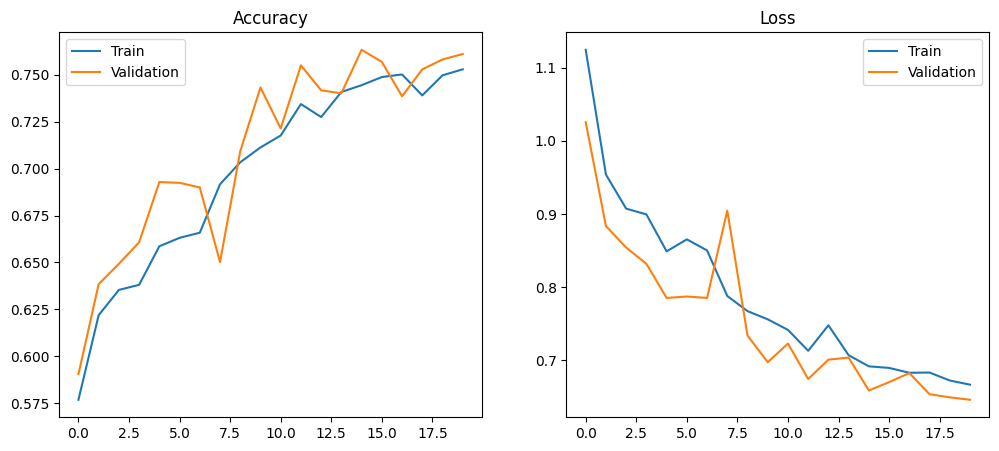

In [62]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")

plt.legend()

plt.show()

## 7. Save 

In [63]:
import pickle

with open("/kaggle/working/simplernn_history.pkl","wb") as f:
    pickle.dump(history.history,f)